In [8]:
import ctypes
import numpy as np
import os
import matplotlib.pyplot as plt


# Chemin absolu vers la DLL
dll_path = "../library/ML_dll.dll"

# Charger la DLL
lib = ctypes.CDLL(dll_path)

# Définir la structure LinearModel en Python
class LinearModel(ctypes.Structure):
    _fields_ = [("weights", ctypes.POINTER(ctypes.c_double)),
                ("bias", ctypes.POINTER(ctypes.c_double)),
                ("loss", ctypes.POINTER(ctypes.c_double)),
                ("loss_size", ctypes.c_size_t)]

# Définir les types de retour et les arguments des fonctions
lib.train_linear_model.restype = LinearModel
lib.train_linear_model.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
                                   ctypes.c_size_t, ctypes.c_size_t, ctypes.c_double, ctypes.c_size_t,
                                   ctypes.c_size_t, ctypes.c_bool]

lib.predict_linear_model.restype = ctypes.POINTER(ctypes.c_double)
lib.predict_linear_model.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
                                     ctypes.POINTER(ctypes.c_double), ctypes.c_size_t, ctypes.c_size_t,
                                     ctypes.c_size_t, ctypes.c_bool]

def train_and_predict():
    # Définir les données d'entraînement
    num_samples = 100
    num_features = 40
    k = 3
    learning_rate = 0.01
    num_iterations = 100000
    isclassification = True

    features = np.random.rand(num_samples, num_features).astype(np.float64)
    outputs = np.random.rand(num_samples, k).astype(np.float64)

    features_ctypes = features.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    outputs_ctypes = outputs.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    # Appeler la fonction d'entraînement
    model = lib.train_linear_model(features_ctypes, outputs_ctypes, num_samples, num_features,
                                   learning_rate, num_iterations, k, isclassification)

    # Afficher les résultats
    weights = [model.weights[i] for i in range(num_features * k)]
    bias = [model.bias[i] for i in range(k)]
    loss_values = [model.loss[i] for i in range(model.loss_size)]

    print("Weights:", weights)
    print("Bias:", bias)
    print("Loss values:", loss_values)

    # Prédire avec le modèle entraîné
    sample = np.random.rand(num_features).astype(np.float64)
    sample_ctypes = sample.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    prediction_ctypes = lib.predict_linear_model(sample_ctypes, model.weights, model.bias, 1, num_features, k, isclassification)
    prediction = [prediction_ctypes[i] for i in range(k)]
    print("Prediction for sample:", sample, "is", prediction)

# Exécuter la fonction de formation et de prédiction
train_and_predict()


Weights: [0.16626016264059548, -0.11098842203834113, -0.07128207935345304, 0.22910542280088766, -0.15392892121452292, 0.12979834221786207, -0.3986036513744694, -0.0889925015157006, 0.030464639325587323, 0.07759680904043487, -0.0910012882180203, 0.06187418446358708, -0.02182911161986948, -0.00711488803545405, 0.15314381566993976, -0.024755406807210095, 0.045565425143121424, 0.10331613076665157, -0.10527267555419904, -0.2090743200991026, -0.0329305333857036, 0.07700543920973361, -0.19261550183511497, -0.028589505235826394, 0.035298342700656335, -0.02311022749431348, 0.08089671833658003, 0.15172076510373003, 0.1701135797683953, 0.14224200030784184, -0.15405720003564535, 0.07807119072152255, -0.13207705930622293, 0.07113836329535583, -0.04106929800365206, -0.23679036115275423, 0.15156171490709117, 0.1828412744219561, -0.05826533779226739, 0.06580146681783101, -0.13305707875117156, -0.1103055689354128, 0.012470922266482005, -0.23071363484036858, -0.02508792472634615, 0.004858052402798919, 0

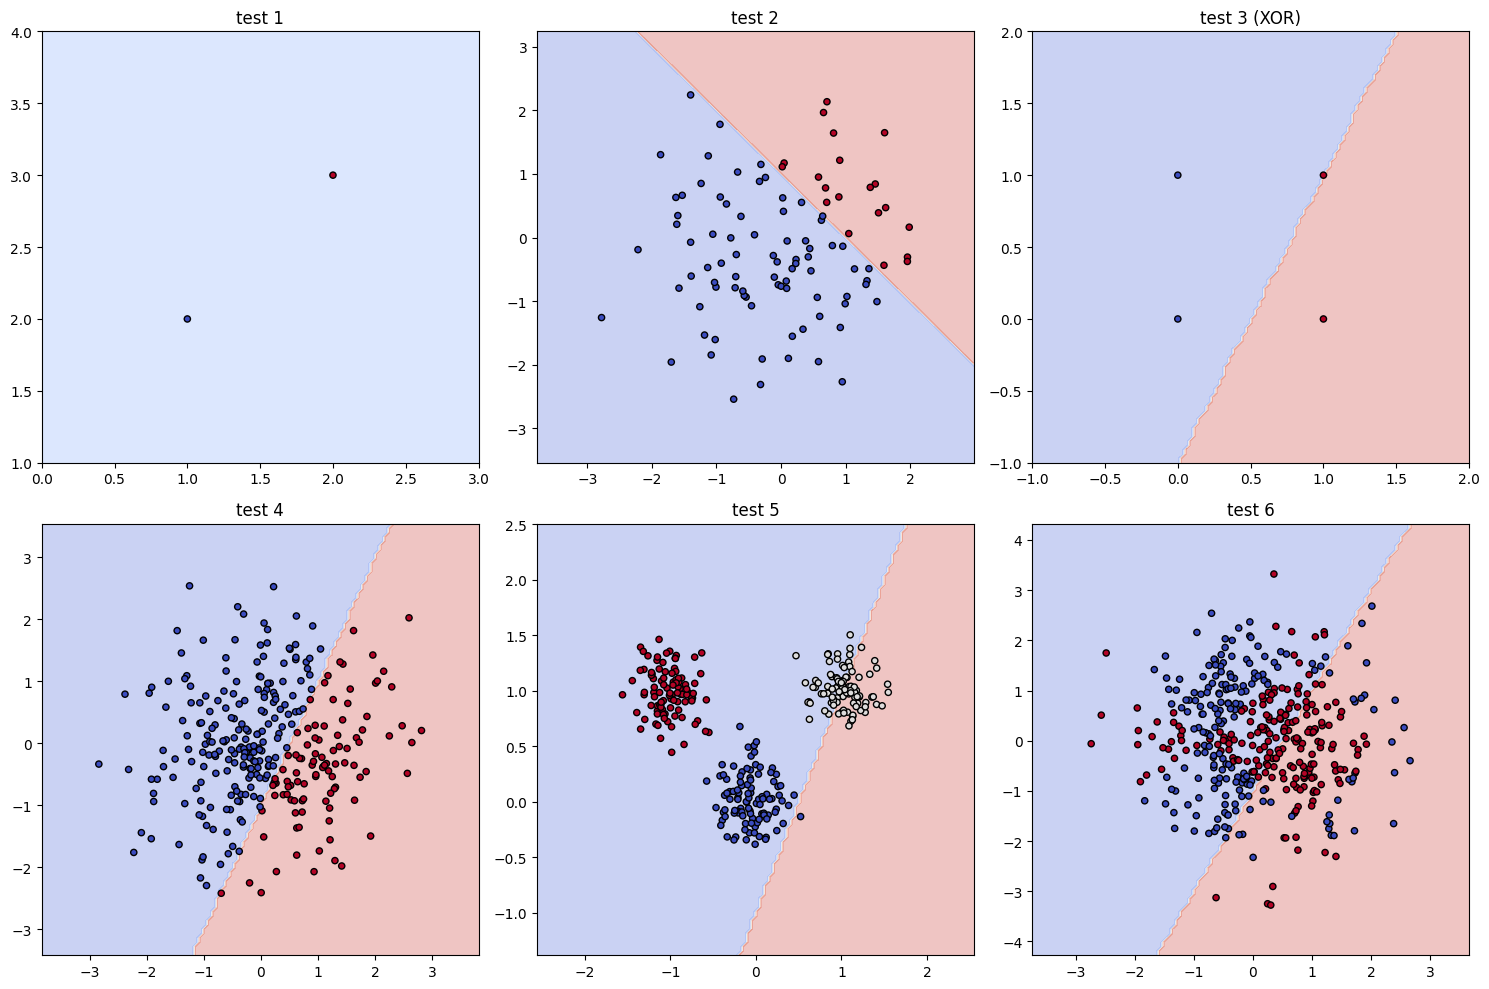

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Fonction pour créer des jeux de données de test
def generate_datasets():
    datasets = []
    
    # Test 1: Simple separation
    X1 = np.array([[1, 2], [2, 3]])
    y1 = np.array([0, 1])
    datasets.append((X1, y1))
    
    # Test 2: Linearly separable
    X2 = np.random.randn(100, 2)
    y2 = (X2[:, 0] + X2[:, 1] > 1).astype(int)
    datasets.append((X2, y2))
    
    # Test 3: XOR
    X3 = np.array([[0, 0], [1, 1], [1, 0], [0, 1]])
    y3 = np.array([0, 1, 1, 0])
    datasets.append((X3, y3))
    
    # Test 4: Two moons-like
    X4 = np.random.randn(300, 2)
    y4 = (X4[:, 0] * 2 - X4[:, 1] > 1).astype(int)
    datasets.append((X4, y4))
    
    # Test 5: Three blobs
    X5, y5 = [], []
    for _ in range(100):
        x, y = np.random.randn(2) * 0.2 + np.array([0, 0])
        X5.append([x, y])
        y5.append(0)
    for _ in range(100):
        x, y = np.random.randn(2) * 0.2 + np.array([1, 1])
        X5.append([x, y])
        y5.append(1)
    for _ in range(100):
        x, y = np.random.randn(2) * 0.2 + np.array([-1, 1])
        X5.append([x, y])
        y5.append(2)
    datasets.append((np.array(X5), np.array(y5)))
    
    # Test 6: Overlapping blobs
    X6 = np.random.randn(400, 2)
    y6 = (np.sin(X6[:, 0] * 2) + np.cos(X6[:, 1] * 2) > 0).astype(int)
    datasets.append((X6, y6))
    
    return datasets

# Fonction pour tracer les frontières de décision (Simple implementation for visualization)
def plot_decision_boundary(X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.zeros(grid.shape[0])
    
    # Simuler une frontière de décision en fonction des étiquettes
    for i, (gx, gy) in enumerate(grid):
        zz[i] = ((gx + gy) > 0.5) if title == 'test 1' else ((gx + gy) > 1.0 if title == 'test 2' else ((gx * 2 - gy) > 1))
    
    zz = zz.reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')
    y = np.array(y)  
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.coolwarm)
datasets = generate_datasets()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

titles = ['test 1', 'test 2', 'test 3 (XOR)', 'test 4', 'test 5', 'test 6']
for (X, y), title, ax in zip(datasets, titles, axes.flatten()):
    y = np.array(y)  
    plot_decision_boundary(X, y, title, ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()
